<a href="https://colab.research.google.com/github/CharalapML/ML_Tests/blob/main/60_NN_IndividualCubes_Individual_Atrributes_20_01_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive
drive.mount('/content/gdrive')
!ls "/content/gdrive/My Drive"

Mounted at /content/gdrive
 CNN_TestData
'Colab Notebooks'
 data_request_2018-09-01_2018-09-05_obspyDMT_data_II-IU-IC-G-GE-GT_simple
 event_list_pickle.txt
'Getting started.pdf'
 inf-openflights
'Initial Document on CFs for Kurtosis .gdoc'
 ISC_RAWFILES
 ISC_RAWFILES_2ndTranche
'readme copy.html'


In [ ]:
import tensorflow as tf
from tensorflow import keras

from keras.layers import Dense, Activation, Flatten

from tensorflow.keras import datasets, layers, models
from keras.layers import UpSampling3D, Conv3DTranspose
from tensorflow.nn import conv3d_transpose

from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#INPUT_4D_DATASET_Xa = np.load("/content/gdrive/My Drive/CNN_TestData/4Darray_1_Unordered_in.npy",  mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')
#RESULT4D_DATASET_ya = np.load("/content/gdrive/My Drive/CNN_TestData/4Darray_1_Unordered_out.npy", mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')

INPUT_4D_DATASET_Xa = np.load("/content/gdrive/My Drive/CNN_TestData/4Darray_2_Ordered_in.npy",  mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')
RESULT4D_DATASET_ya = np.load("/content/gdrive/My Drive/CNN_TestData/4Darray_2_Ordered_out.npy", mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')

print("INPUT_4D_DATASET_Xa NaNs   = ", np.count_nonzero(np.isnan(INPUT_4D_DATASET_Xa)) )
print("RESULT4D_DATASET_ya NaNs   = ", np.count_nonzero(np.isnan(RESULT4D_DATASET_ya)) )
print('\n', "--------------------", '\n')
RESULT4D_DATASET_ya = np.nan_to_num(RESULT4D_DATASET_ya, copy=True, nan=0.0, posinf=None, neginf=None) # removes NaNs !!!

print("INPUT_4D_DATASET_Xa NaNs   = ", np.count_nonzero(np.isnan(INPUT_4D_DATASET_Xa)) )
print("RESULT4D_DATASET_ya NaNs   = ", np.count_nonzero(np.isnan(RESULT4D_DATASET_ya)) )

print("INPUT_4D_DATASET_Xa type   = ", type(INPUT_4D_DATASET_Xa))

print("INPUT_4D_DATASET_Xa length = ", len(INPUT_4D_DATASET_Xa))
print("INPUT_4D_DATASET_Xa.shape  = ", INPUT_4D_DATASET_Xa.shape)
print("INPUT_4D_DATASET_Xa size   = ", INPUT_4D_DATASET_Xa.size)
print('\n', "--------------------", '\n')
print("RESULT4D_DATASET_ya length = ", len(RESULT4D_DATASET_ya))
print("RESULT4D_DATASET_ya.shape  = ", RESULT4D_DATASET_ya.shape)
print("RESULT4D_DATASET_ya size   = ", RESULT4D_DATASET_ya.size)

INPUT_4D_DATASET_Xa NaNs   =  0
RESULT4D_DATASET_ya NaNs   =  16000

 -------------------- 

INPUT_4D_DATASET_Xa NaNs   =  0
RESULT4D_DATASET_ya NaNs   =  0
INPUT_4D_DATASET_Xa type   =  <class 'numpy.ndarray'>
INPUT_4D_DATASET_Xa length =  4
INPUT_4D_DATASET_Xa.shape  =  (4, 10, 5, 8000)
INPUT_4D_DATASET_Xa size   =  1600000

 -------------------- 

RESULT4D_DATASET_ya length =  4
RESULT4D_DATASET_ya.shape  =  (4, 10, 1, 8000)
RESULT4D_DATASET_ya size   =  320000


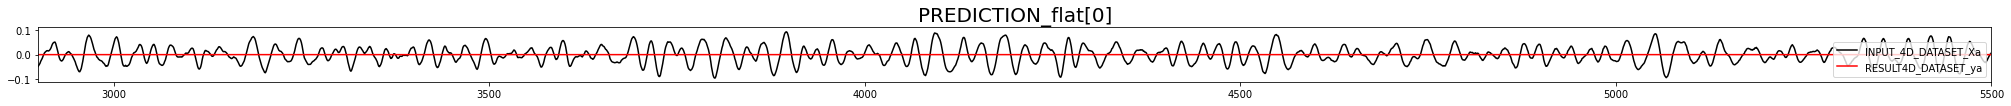

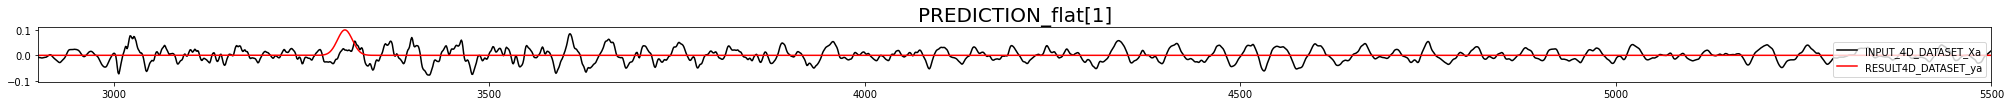

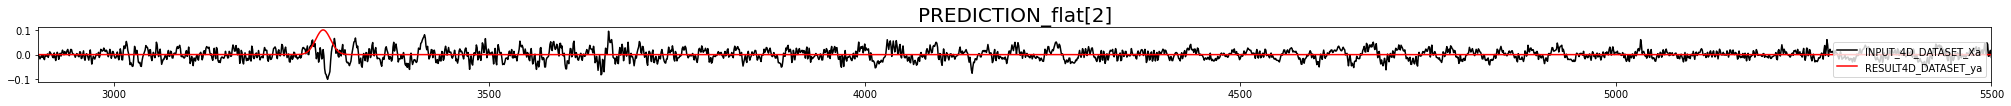

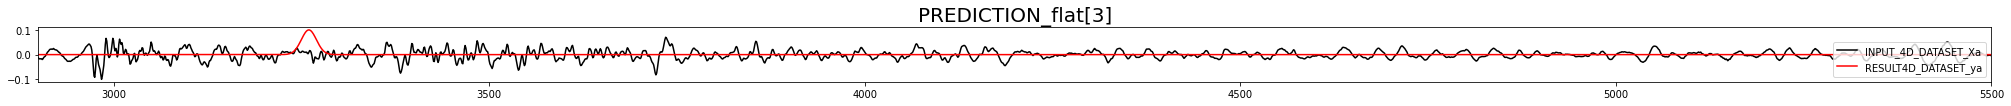

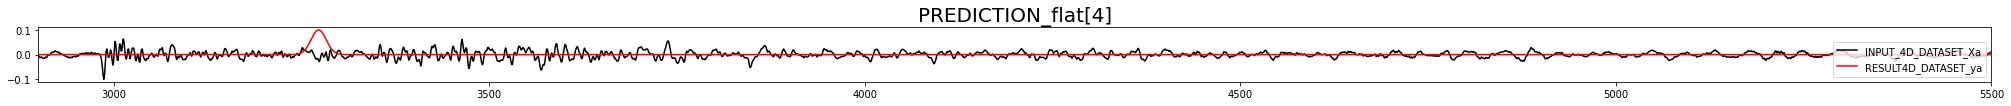

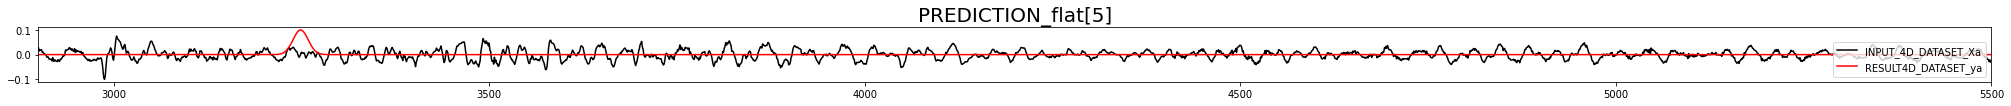

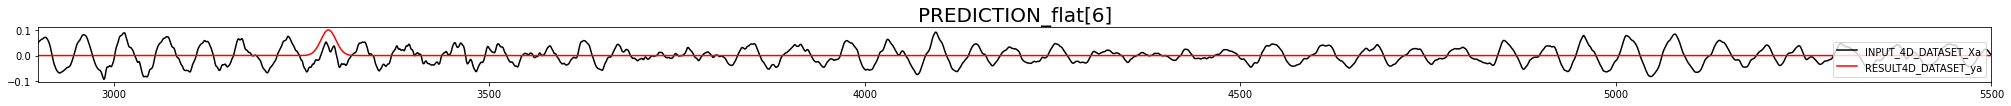

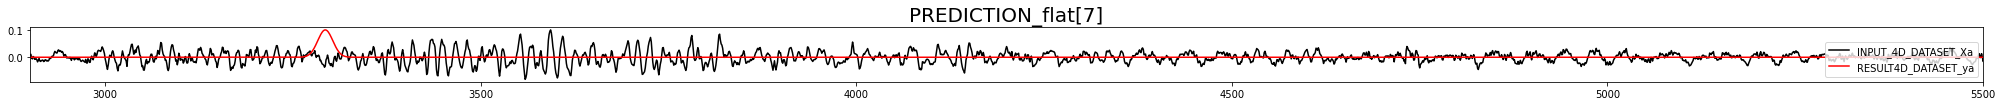

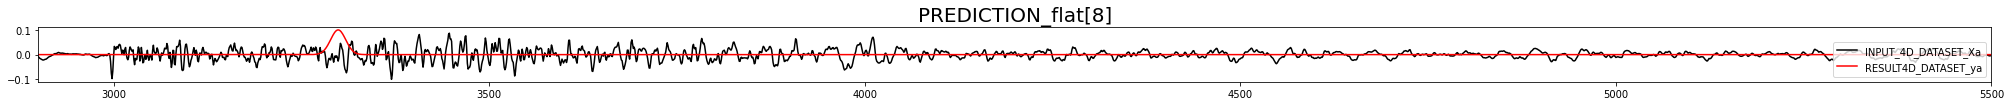

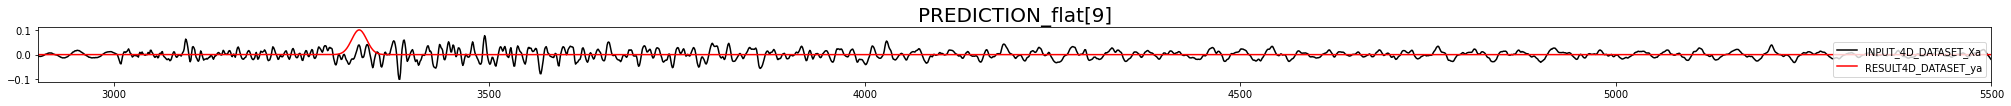

In [ ]:
for nn in range(0,10):
  plt.figure(figsize=(35, 1))
  plt.title( label='PREDICTION_flat[nn]'.replace("nn",str(nn)[0]), size=20)
  plt.plot(((INPUT_4D_DATASET_Xa[3:4,nn:nn+1,0:1,:]).flatten())/10, label='INPUT_4D_DATASET_Xa', color= 'black')
  #plt.plot(((INPUT_4D_DATASET_train[0:1,nn:nn+1,1:2,:]).flatten())/10, label='INPUT_4D_DATASET_test', color= 'red')
  #plt.plot(((INPUT_4D_DATASET_train[0:1,nn:nn+1,2:3,:]).flatten())/10, label='INPUT_4D_DATASET_test', color= 'orange')
  plt.plot(((RESULT4D_DATASET_ya[3:4,nn:nn+1,0:1,:]).flatten())/10, label='RESULT4D_DATASET_ya', color= 'red')
  plt.xlim(2900,5500)
  plt.legend(loc='lower right')
  plt.show()


In [ ]:
INPUT_4D_DATASET_X = np.expand_dims(INPUT_4D_DATASET_Xa, axis=-1)

print("INPUT_4D_DATASET_X length = ", len(INPUT_4D_DATASET_X))
print("INPUT_4D_DATASET_X.shape  = ", INPUT_4D_DATASET_X.shape)
print("INPUT_4D_DATASET_X size   = ", INPUT_4D_DATASET_X.size)
print("INPUT_4D_DATASET_X NaNs   = ", np.count_nonzero(np.isnan(INPUT_4D_DATASET_X)) )

print('\n', "--------------------", '\n')
print("RESULT4D_DATASET_ya length = ", len(RESULT4D_DATASET_ya))
print("RESULT4D_DATASET_ya.shape  = ", RESULT4D_DATASET_ya.shape)
print("RESULT4D_DATASET_ya size   = ", RESULT4D_DATASET_ya.size)
print("RESULT4D_DATASET_ya NaNs   = ", np.count_nonzero(np.isnan(RESULT4D_DATASET_ya)) )

INPUT_4D_DATASET_X length =  4
INPUT_4D_DATASET_X.shape  =  (4, 10, 5, 8000, 1)
INPUT_4D_DATASET_X size   =  1600000
INPUT_4D_DATASET_X NaNs   =  0

 -------------------- 

RESULT4D_DATASET_ya length =  4
RESULT4D_DATASET_ya.shape  =  (4, 10, 1, 8000)
RESULT4D_DATASET_ya size   =  320000
RESULT4D_DATASET_ya NaNs   =  0


In [ ]:
#  THIS CELL OF CODE WILL EXTRACT A GIVEN ATTRIBUTE FROM THE ORIGINAL 5 ATTRIBUTE 4D INPUT DATASET
#  ATTRIBUTE 1 (ie python number 0)  = Original splined scaled signal
#  ATTRIBUTE 2 (ie python number 1)  = F1cf               attribute
#  ATTRIBUTE 3 (ie python number 2)  = F4cf               attribute
#  ATTRIBUTE 4 (ie python number 3)  = F4cfgrad           attribute
#  ATTRIBUTE 5 (ie python number 4)  = F4cfgrad_gtmean    attribute


INPUT_4D_DATASET_Signal             = INPUT_4D_DATASET_Xa[:,:,0:1,:]
INPUT_4D_DATASET_F1cf               = INPUT_4D_DATASET_Xa[:,:,1:2,:]
INPUT_4D_DATASET_F4cf               = INPUT_4D_DATASET_Xa[:,:,2:3,:]
INPUT_4D_DATASET_F4cfgrad           = INPUT_4D_DATASET_Xa[:,:,3:4,:]
INPUT_4D_DATASET_F4cfgrad_gtmean    = INPUT_4D_DATASET_Xa[:,:,4:5,:]

print("INPUT_4D_DATASET_Signal type   = ", type(INPUT_4D_DATASET_Xa))
print("INPUT_4D_DATASET_Signal length = ", len(INPUT_4D_DATASET_Signal))
print("INPUT_4D_DATASET_Signal.shape  = ", INPUT_4D_DATASET_Signal.shape)
print("INPUT_4D_DATASET_Signal size   = ", INPUT_4D_DATASET_Signal.size)

# WE THEN ADD THE EXTRA DIMENSION FOR THE CNN

INPUT_4D_DATASET_SignalX = np.expand_dims(INPUT_4D_DATASET_Signal, axis=-1)
INPUT_4D_DATASET_F1cfX = np.expand_dims(INPUT_4D_DATASET_F1cf, axis=-1)
INPUT_4D_DATASET_F4cfX = np.expand_dims(INPUT_4D_DATASET_F4cf, axis=-1)
INPUT_4D_DATASET_F4cfgradX = np.expand_dims(INPUT_4D_DATASET_F4cfgrad, axis=-1)
INPUT_4D_DATASET_F4cfgrad_gtmeanX = np.expand_dims(INPUT_4D_DATASET_F4cfgrad_gtmean, axis=-1)


print('\n', "--------------------", '\n')
print("INPUT_4D_DATASET_SignalX length = ", len(INPUT_4D_DATASET_SignalX))
print("INPUT_4D_DATASET_SignalX.shape  = ", INPUT_4D_DATASET_SignalX.shape)
print("INPUT_4D_DATASET_SignalX size   = ", INPUT_4D_DATASET_SignalX.size)
print('\n', "--------------------", '\n')

print("INPUT_4D_DATASET_Signal.shape           = ", INPUT_4D_DATASET_Signal.shape)
print("INPUT_4D_DATASET_F1cf.shape             = ", INPUT_4D_DATASET_F1cf.shape)
print("INPUT_4D_DATASET_F4cf.shape             = ", INPUT_4D_DATASET_F4cf.shape)
print("INPUT_4D_DATASET_F4cfgrad.shape         = ", INPUT_4D_DATASET_F4cfgrad.shape)
print("INPUT_4D_DATASET_F4cfgrad_gtmean.shape  = ", INPUT_4D_DATASET_F4cfgrad_gtmean.shape)

INPUT_4D_DATASET_Signal type   =  <class 'numpy.ndarray'>
INPUT_4D_DATASET_Signal length =  4
INPUT_4D_DATASET_Signal.shape  =  (4, 10, 1, 8000)
INPUT_4D_DATASET_Signal size   =  320000

 -------------------- 

INPUT_4D_DATASET_SignalX length =  4
INPUT_4D_DATASET_SignalX.shape  =  (4, 10, 1, 8000, 1)
INPUT_4D_DATASET_SignalX size   =  320000

 -------------------- 

INPUT_4D_DATASET_Signal.shape           =  (4, 10, 1, 8000)
INPUT_4D_DATASET_F1cf.shape             =  (4, 10, 1, 8000)
INPUT_4D_DATASET_F4cf.shape             =  (4, 10, 1, 8000)
INPUT_4D_DATASET_F4cfgrad.shape         =  (4, 10, 1, 8000)
INPUT_4D_DATASET_F4cfgrad_gtmean.shape  =  (4, 10, 1, 8000)


In [ ]:
#Input Dimensions
num_events     = 4     # number of unique sources e.g Individual EarthQuakes
num_receivers  = 10    # number of unique recordings for each source (EarthQuakes)
num_attributes = 1     # number of attributes for each recording (for each source (EarthQuakes))
trace_length   = 8000  # number of samples in each attributes

#output_dim     = (trace_length*num_receivers)  # number of samples in the result trace
output_dim     = (num_events*num_receivers*1*trace_length)  # number of samples in the result trace

In [ ]:
#INPUT_4D_DATASET_X  = np.random.rand(num_events, num_receivers, num_attributes, trace_length,1)
#INPUT_4D_DATASET_X  = 2*INPUT_4D_DATASET_X - 1
#RESULT_2D_DATASET_y = np.random.rand(num_events, num_receivers, trace_length, 1)

In [ ]:

INPUT_4D_DATASET_train, INPUT_4D_DATASET_test, RESULT4D_DATASET_train, RESULT4D_DATASET_test = train_test_split(
    INPUT_4D_DATASET_F4cfgrad_gtmeanX, RESULT4D_DATASET_ya, test_size=0.25)  # random_state=42

print('\n', "--------------------", '\n')

#RESULT4D_DATASET_train_flat = Flatten()(RESULT4D_DATASET_train)
RESULT4D_DATASET_train_flat = (RESULT4D_DATASET_train).flatten()
print('RESULT4D_DATASET_train_flat.shape = ', RESULT4D_DATASET_train_flat.shape)

print("RESULT4D_DATASET_train_flatnumber of Nans=",  np.count_nonzero(np.isnan(RESULT4D_DATASET_train_flat)))
print('\n', "--------------------", '\n')

print("INPUT_4D_DATASET_train length = ", len(INPUT_4D_DATASET_train))
print("INPUT_4D_DATASET_train.shape  = ", INPUT_4D_DATASET_train.shape)
print("INPUT_4D_DATASET_train size   = ", INPUT_4D_DATASET_train.size)
print('\n', "--------------------", '\n')
print("RESULT4D_DATASET_train length = ", len(RESULT4D_DATASET_train))
print("RESULT4D_DATASET_train.shape  = ", RESULT4D_DATASET_train.shape)
print("RESULT4D_DATASET_train size   = ", RESULT4D_DATASET_train.size)
print('\n', "--------------------", '\n')
print("INPUT_4D_DATASET_test.shape  = ", INPUT_4D_DATASET_test.shape)
print("RESULT4D_DATASET_test.shape  = ", RESULT4D_DATASET_test.shape)



 -------------------- 

RESULT4D_DATASET_train_flat.shape =  (240000,)
RESULT4D_DATASET_train_flatnumber of Nans= 0

 -------------------- 

INPUT_4D_DATASET_train length =  3
INPUT_4D_DATASET_train.shape  =  (3, 10, 1, 8000, 1)
INPUT_4D_DATASET_train size   =  240000

 -------------------- 

RESULT4D_DATASET_train length =  3
RESULT4D_DATASET_train.shape  =  (3, 10, 1, 8000)
RESULT4D_DATASET_train size   =  240000

 -------------------- 

INPUT_4D_DATASET_test.shape  =  (1, 10, 1, 8000, 1)
RESULT4D_DATASET_test.shape  =  (1, 10, 1, 8000)


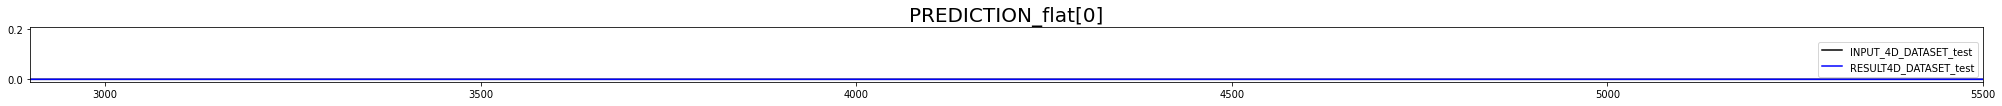

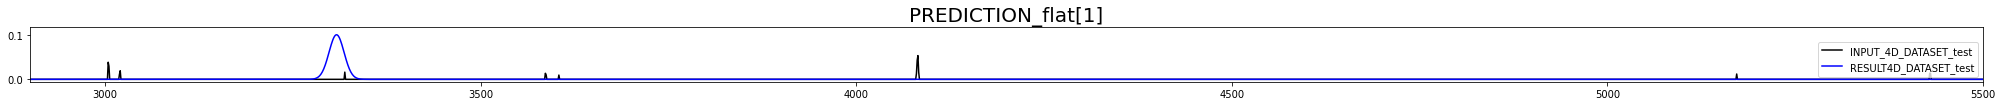

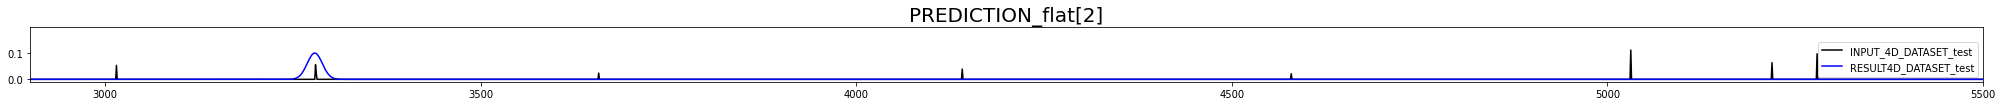

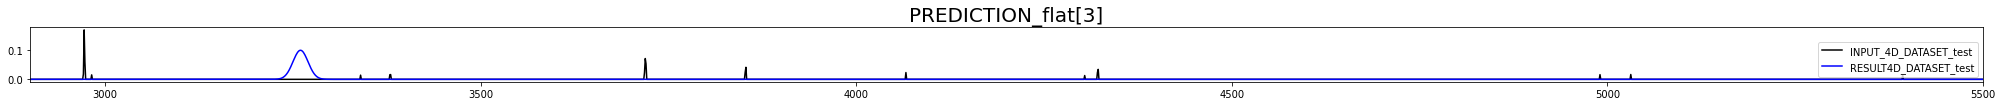

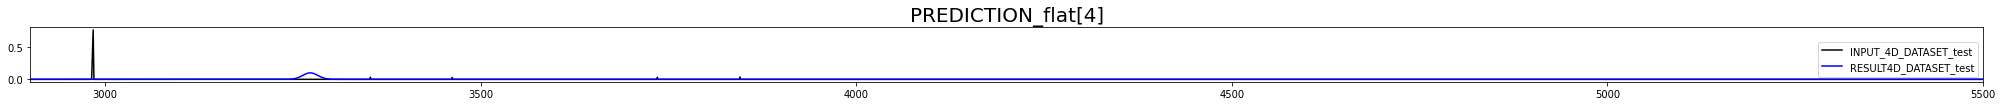

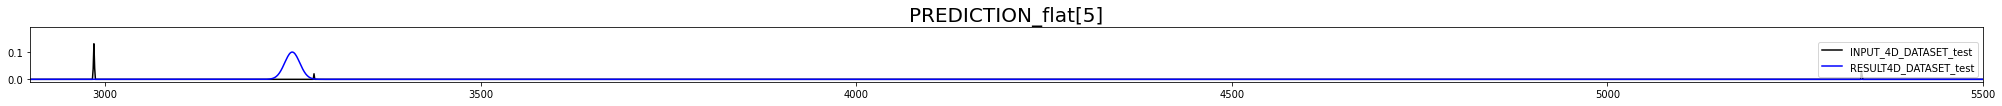

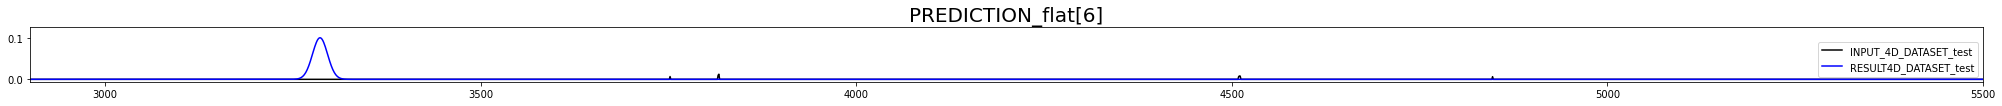

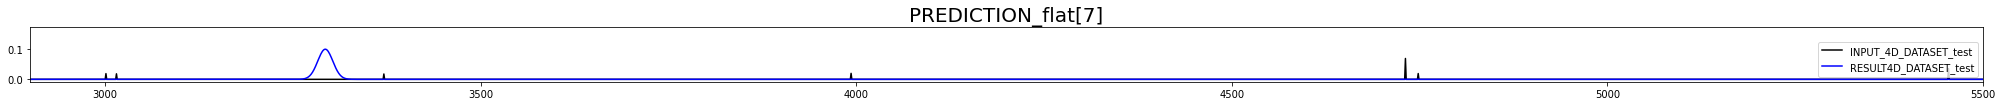

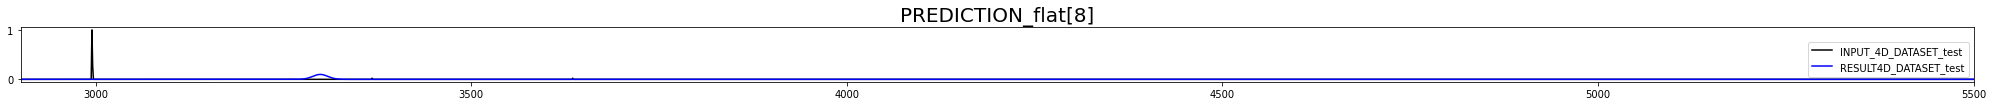

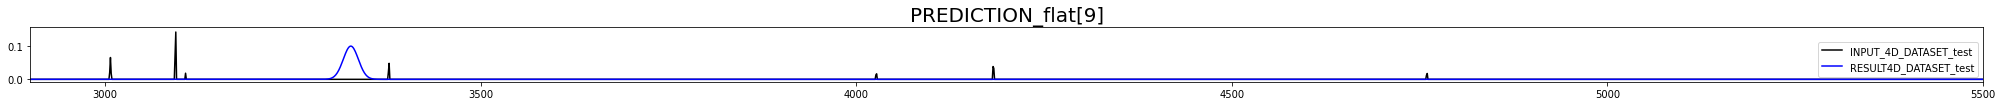

In [ ]:
for nn in range(0,10):
  plt.figure(figsize=(35, 1))
  plt.title( label='PREDICTION_flat[nn]'.replace("nn",str(nn)[0]), size=20)
  plt.plot(((INPUT_4D_DATASET_train[1:2,nn:nn+1,0:1,:]).flatten())/10, label='INPUT_4D_DATASET_test', color= 'black')
  #plt.plot(((INPUT_4D_DATASET_train[1:2,nn:nn+1,1:2,:]).flatten())/10, label='INPUT_4D_DATASET_test', color= 'red')
  #plt.plot(((INPUT_4D_DATASET_train[1:2,nn:nn+1,2:3,:]).flatten())/10, label='INPUT_4D_DATASET_test', color= 'orange')
  plt.plot(((RESULT4D_DATASET_train[1:2,nn:nn+1,0:1,:]).flatten())/10, label='RESULT4D_DATASET_test', color= 'blue')
  plt.xlim(2900,5500)
  plt.legend(loc='lower right')
  plt.show()


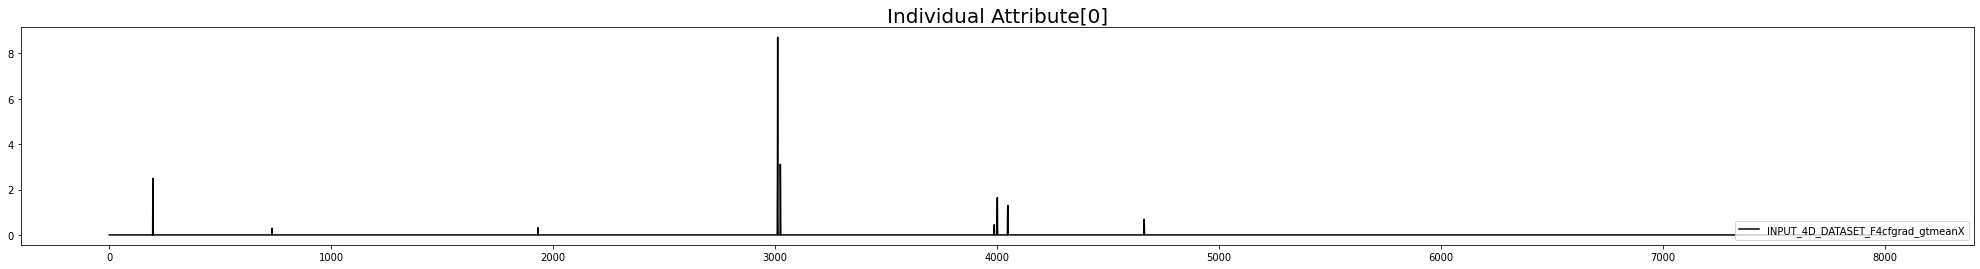

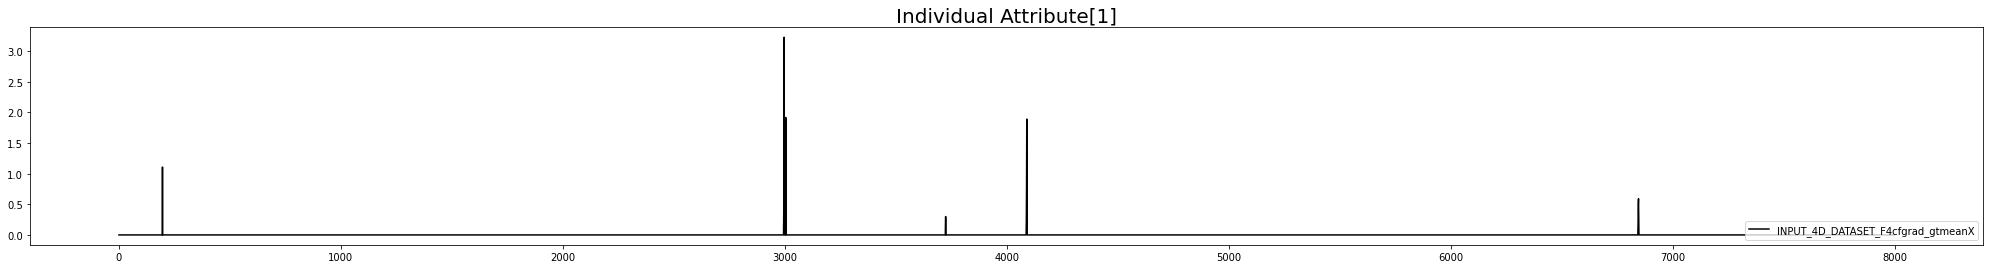

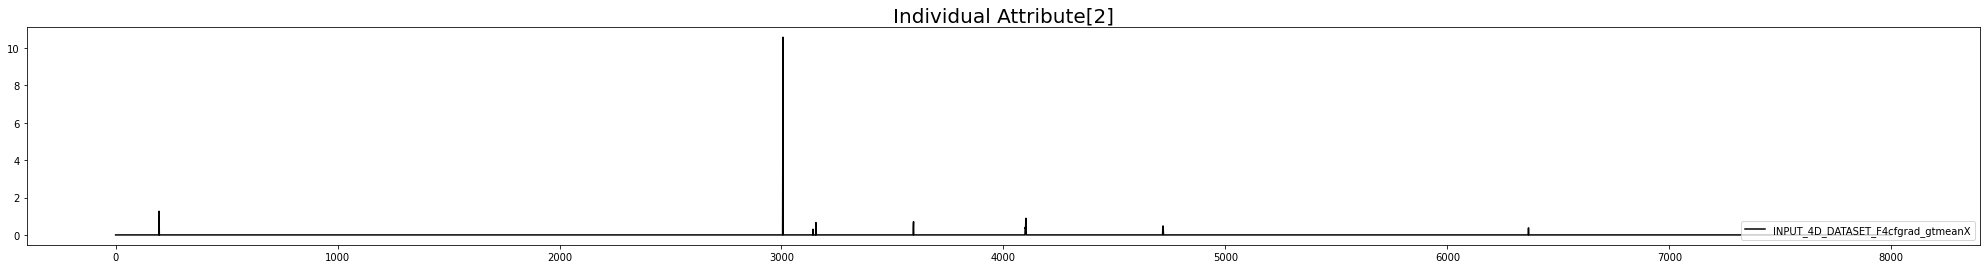

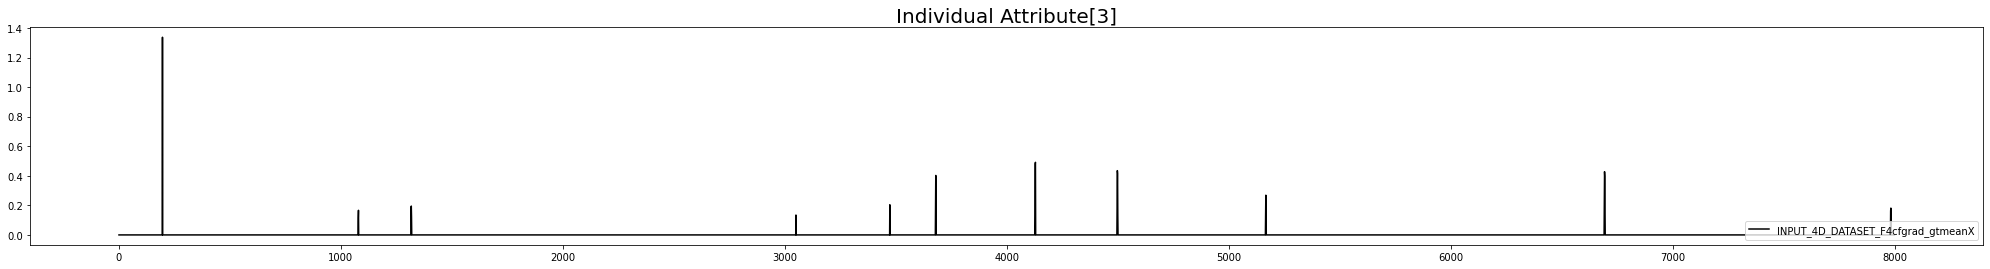

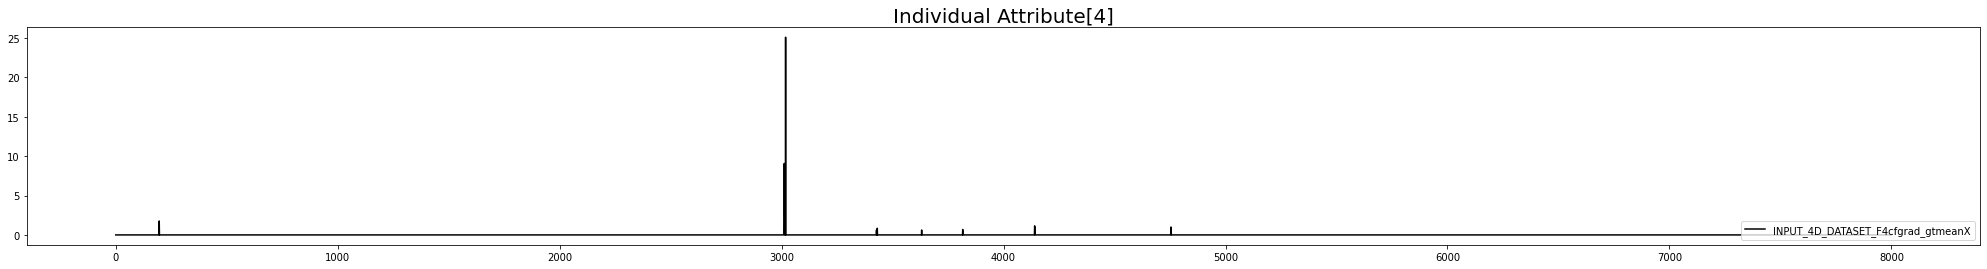

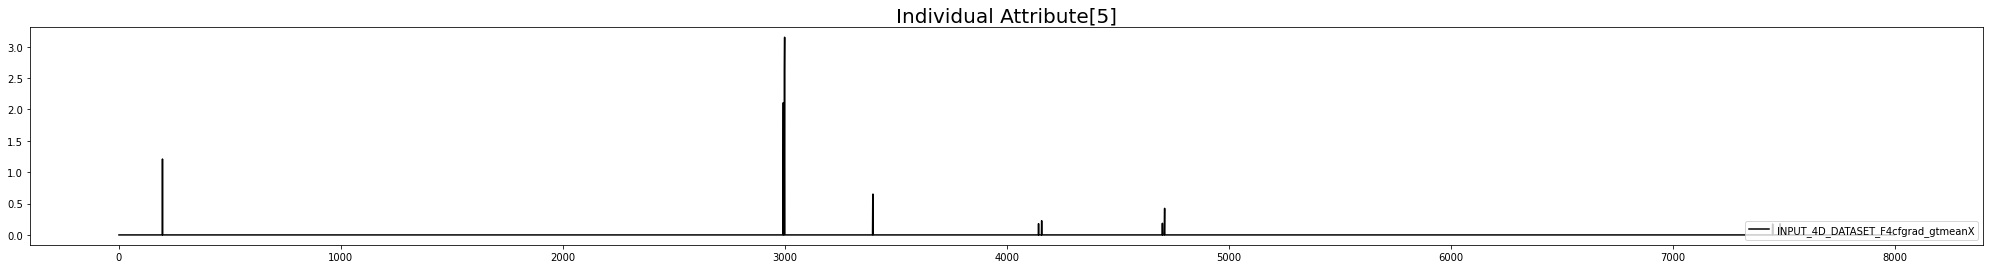

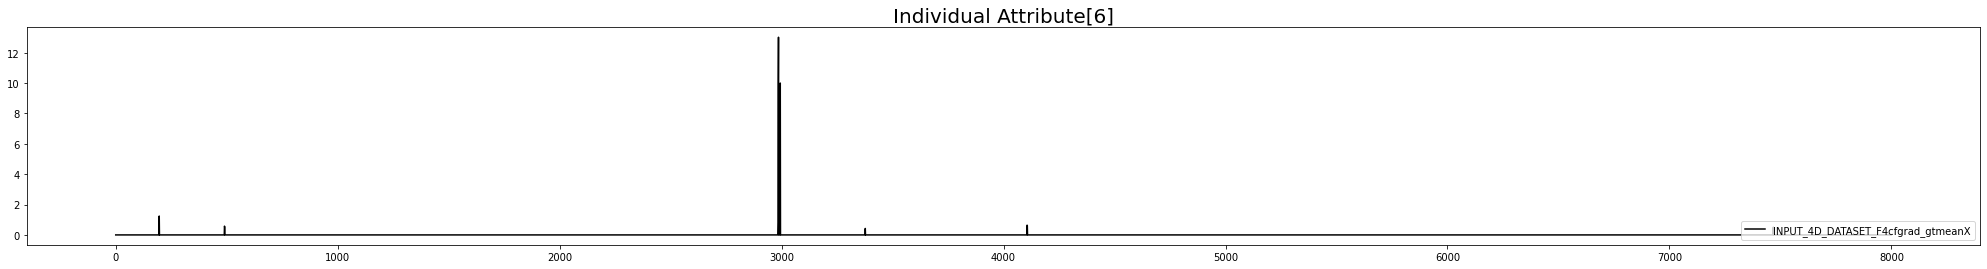

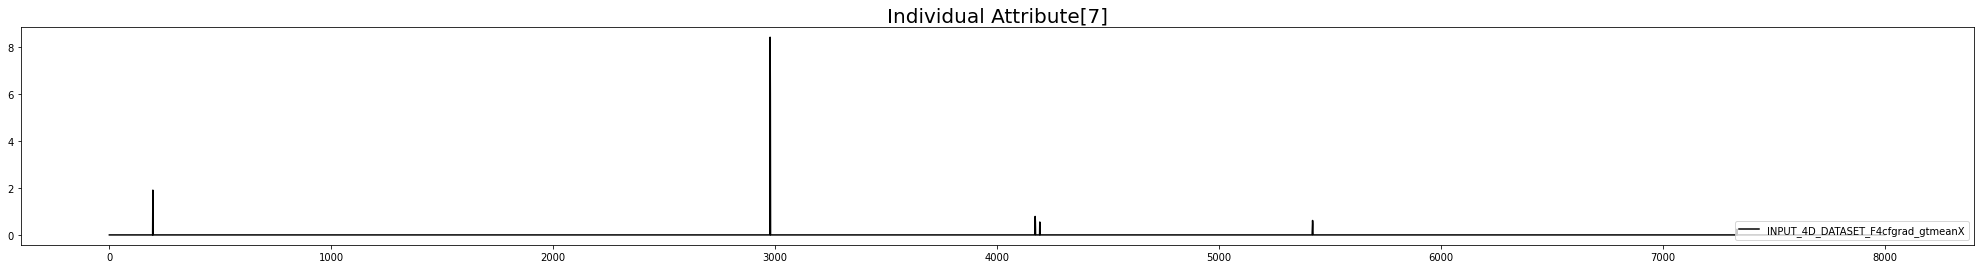

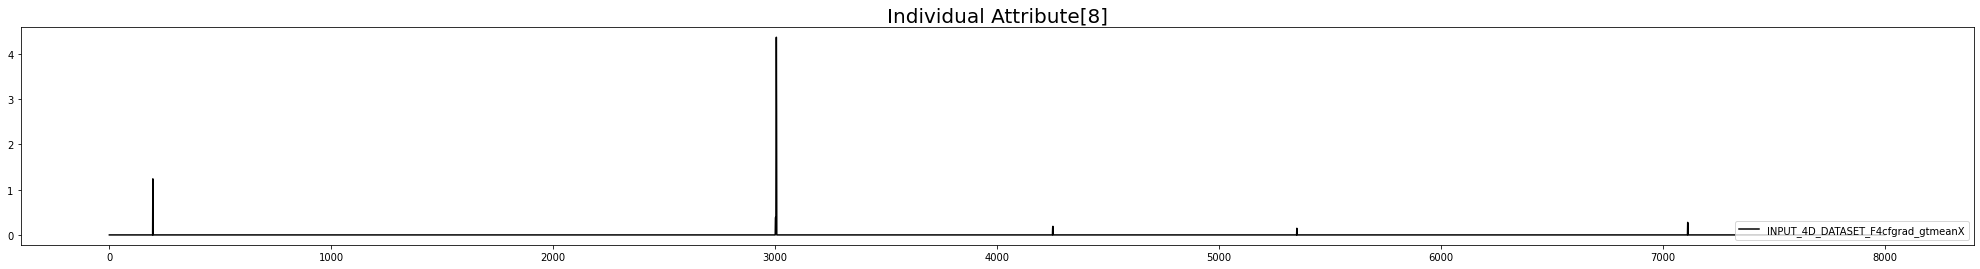

In [ ]:

for nn in range(0,9):
  plt.figure(figsize=(35, 4))
  plt.title( label='Individual Attribute[nn]'.replace("nn",str(nn)[0]), size=20)
  #plt.plot((INPUT_4D_DATASET_SignalX[1:2, nn:nn+1, 0:1, 0:, :]).flatten(), label ='INPUT_4D_DATASET_SignalX', color= 'black')
  #plt.plot((INPUT_4D_DATASET_F1cfX[1:2, nn:nn+1, 0:1, 0:, :]).flatten(), label ='INPUT_4D_DATASET_F1cfX', color= 'black')
  #plt.plot((INPUT_4D_DATASET_F4cfX[1:2, nn:nn+1, 0:1, 0:, :]).flatten(), label ='INPUT_4D_DATASET_F4cfX', color= 'black')
  #plt.plot((INPUT_4D_DATASET_F4cfgradX[1:2, nn:nn+1, 0:1, 0:, :]).flatten(), label ='INPUT_4D_DATASET_F4cfgradX', color= 'black')
  plt.plot((INPUT_4D_DATASET_F4cfgrad_gtmeanX[1:2, nn:nn+1, 0:1, 0:, :]).flatten(), label ='INPUT_4D_DATASET_F4cfgrad_gtmeanX', color= 'black')

  #plt.xlim(2900,5500)
  plt.legend(loc='lower right')
  plt.show()


In [ ]:
#INPUT_4D_DATASET_train =
#RESULT_2D_DATASET_test =

# building the network
input = keras.Input((num_receivers, num_attributes, trace_length, 1))

x = layers.Conv3D (filters = 32, padding ='same', kernel_size = (1, 1, 2), strides = 1)(input)
print (' x after conv', x.shape)
x = layers.MaxPool3D(pool_size= (1, 1, 2), strides = (1,1,2))(x)  # only pools the data along length of each trace
print (' x after maxpool', x.shape)

x1 = layers.Conv3D(16, padding ='same', kernel_size=(1,1,5), activation='relu', strides = 1)(x)
print ('x1 after conv', x1.shape)
x1 = layers.MaxPool3D(pool_size=(1, 1, 2), strides =(1, 1, 2))(x1)   # Again only pools the data along length of each trace
print ('x1 after maxpool', x1.shape)

x2 = layers.Conv3D(8, padding ='same', kernel_size=(1,1,2), activation='relu', use_bias= True, strides = 1)(x1)
print (' x2 after conv', x2.shape)
x2 = layers.MaxPool3D(pool_size=(1, 1, 2), strides =(1, 1, 2))(x2)
print (' x2 after maxpool', x2.shape)

x3 = layers.Conv3D(8, padding ='same', kernel_size=(1,1,5), activation='relu', strides = (1,1,5))(x2)
print ('x3 after conv conv3D', x3.shape)


y3 = layers.Conv3DTranspose(8, padding ='same', kernel_size=(1, 1, 5), )(x3) # back to x2? or x3
print (' y3 after conv3Dtranspose', y3.shape)
y3 = tf.keras.layers.Concatenate()([y3, x3])               #CONCATENATION
print (' >>>>> y3 + x3 shape', y3.shape)

y3 = UpSampling3D((1, 1, 5))(y3)
print (' y3 after UpSampling3D', y3.shape)

y2 = layers.Conv3DTranspose(8, padding ='same', kernel_size=(1, 1, 2))(y3) # back to x2? or x3
print ('y2 after conv3Dtranspose', y2.shape)
y2 = tf.keras.layers.Concatenate()([y2, x2])              #CONCATENATION
print (' >>>>> y2 + x2 shape', y2.shape)
y2 = UpSampling3D((1, 1, 2))(y2)
print ('y2 UpSampling3D', y2.shape)

y1 = layers.Conv3DTranspose(16, padding ='same', kernel_size=(1, 1, 5))(y2) # back to x2? or x3
print (' y1 after conv3Dtranspose', y1.shape)
y1 = tf.keras.layers.Concatenate()([y1, x1])        #CONCATENATION
print (' >>>>> y1 + x1 shape', y1.shape)
print("y1 dtype = ", y1.dtype)

y1 = UpSampling3D((1, 1, 4))(y1)
print (' y1 UpSampling3D', y1.shape)

y = layers.Conv3DTranspose(32, padding ='same', kernel_size=(1, 1, 4))(y1)  # back to x1? or x2
print ('final conv3DTranspose', y.shape)

OUT = layers.MaxPool3D(pool_size=(1, 1, 1), strides =(1, 5, 1))(y)   # Again only pools the data along length of each trace
print ('OUT after maxpool', OUT.shape)

OUT2 = layers.Conv3D (filters = 1, padding ='same', kernel_size = (1, 1, 1), strides = 1)(OUT)
print (' OUT2', OUT2.shape)

#x = layers.Flatten()(y)
#print(x.shape)

#print (model.summary())
#x = layers.Dense(64, activation="relu")(y)

#outputs = layers.Dense(trace_length, activation='softmax')(x)
#outputs = layers.Dense((num_events*num_receivers*1*trace_length), activation='softmax')(x)

# training the network
#training_data = INPUT_4D_DATASET_X(num_events, num_receivers, num_attributes, trace_length)

#training_data = INPUT_4D_DATASET_X(num_events, num_receivers, num_attributes, trace_length)

model = tf.keras.Model(inputs = input, outputs = OUT2 )
model.summary()

 x after conv (None, 10, 1, 8000, 32)
 x after maxpool (None, 10, 1, 4000, 32)
x1 after conv (None, 10, 1, 4000, 16)
x1 after maxpool (None, 10, 1, 2000, 16)
 x2 after conv (None, 10, 1, 2000, 8)
 x2 after maxpool (None, 10, 1, 1000, 8)
x3 after conv conv3D (None, 10, 1, 200, 8)
 y3 after conv3Dtranspose (None, 10, 1, 200, 8)
 >>>>> y3 + x3 shape (None, 10, 1, 200, 16)
 y3 after UpSampling3D (None, 10, 1, 1000, 16)
y2 after conv3Dtranspose (None, 10, 1, 1000, 8)
 >>>>> y2 + x2 shape (None, 10, 1, 1000, 16)
y2 UpSampling3D (None, 10, 1, 2000, 16)
 y1 after conv3Dtranspose (None, 10, 1, 2000, 16)
 >>>>> y1 + x1 shape (None, 10, 1, 2000, 32)
y1 dtype =  <dtype: 'float32'>
 y1 UpSampling3D (None, 10, 1, 8000, 32)
final conv3DTranspose (None, 10, 1, 8000, 32)
OUT after maxpool (None, 10, 1, 8000, 32)
 OUT2 (None, 10, 1, 8000, 1)
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape      

(240000,)


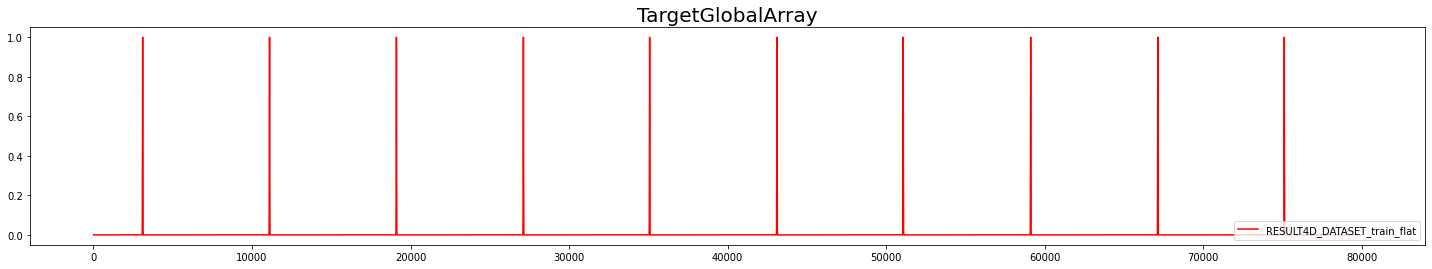

In [ ]:
"""
k = (TargetGlobalArray[3:4,8:9,0:1,:]).flatten()
#k = k.flatten()

"""
print(RESULT4D_DATASET_train_flat.shape)
#print(np.argmax(k))

plt.figure(figsize=(25, 4))
plt.title( label='TargetGlobalArray', size=20)
plt.plot(RESULT4D_DATASET_train_flat[160000:240000], label='RESULT4D_DATASET_train_flat', color= 'red')
plt.legend(loc='lower right')
plt.show()



In [ ]:
#model.compile(optimizer = "adam", loss = 'mean_squared_error', metrics=['accuracy'])
model.compile(optimizer='adam', loss=tf.keras.losses.mean_squared_error,  metrics=['accuracy'])

#  TRAIN the MODEL
model.fit(INPUT_4D_DATASET_train, RESULT4D_DATASET_train, epochs =10)

predictions = model.predict(INPUT_4D_DATASET_test)
errors = []
"""
for i in range(len(predictions)):
  prediction = predictions[i]
  error = sum(abs(prediction - INPUT_4D_DATASET_test[i]))
  errors.append(error)
"""
#plt.plot(errors)

print('\n', "--------------------", '\n')
print("predictions.shape", predictions.shape)
print('\n', "--------------------", '\n')
predictions_reshp = predictions.reshape(num_receivers, trace_length )

Epoch 1/10
1/1 [==============================] - 68s 68s/step - loss: 0.0031 - accuracy: 0.9879
Epoch 2/10
1/1 [==============================] - 2s 2s/step - loss: 0.0029 - accuracy: 0.9877
Epoch 3/10
1/1 [==============================] - 2s 2s/step - loss: 0.0026 - accuracy: 0.9876
Epoch 4/10
1/1 [==============================] - 2s 2s/step - loss: 0.0025 - accuracy: 0.9877
Epoch 5/10
1/1 [==============================] - 2s 2s/step - loss: 0.0025 - accuracy: 0.9878
Epoch 6/10
1/1 [==============================] - 2s 2s/step - loss: 0.0024 - accuracy: 0.9878
Epoch 7/10
1/1 [==============================] - 2s 2s/step - loss: 0.0023 - accuracy: 0.9878
Epoch 8/10
1/1 [==============================] - 2s 2s/step - loss: 0.0023 - accuracy: 0.9879
Epoch 9/10
1/1 [==============================] - 2s 2s/step - loss: 0.0024 - accuracy: 0.9879
Epoch 10/10
1/1 [==============================] - 1s 1s/step

 -------------------- 

predictions.shape (1, 10, 1, 8000, 1)

 ----------------

In [ ]:
pip install visualkeras

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 992 kB 4.9 MB/s 


In [ ]:
import visualkeras

In [ ]:
from collections import defaultdict
color_map = defaultdict(dict)                    #customize the colours
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.Dropout]['fill'] = '#03045e'
color_map[layers.Dense]['fill'] = '#fb5607'
color_map[layers.Flatten]['fill'] = '#ffbe0b'

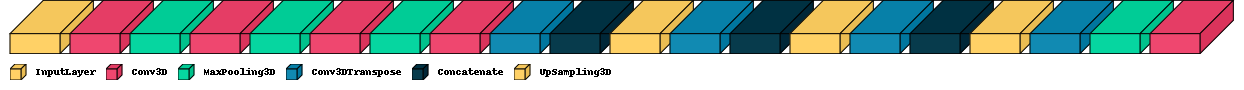

In [ ]:
visualkeras.layered_view(model, legend=True, scale_xy=10, scale_z=10, max_z=50) # without custom font
#from PIL import ImageFont, ImageDraw
#font = ImageFont.truetype("arial.ttf", 12)
#visualkeras.layered_view(model, legend=True, font=font) # selected font
#visualkeras.layered_view(model, legend=True, color_map=color_map) # no font

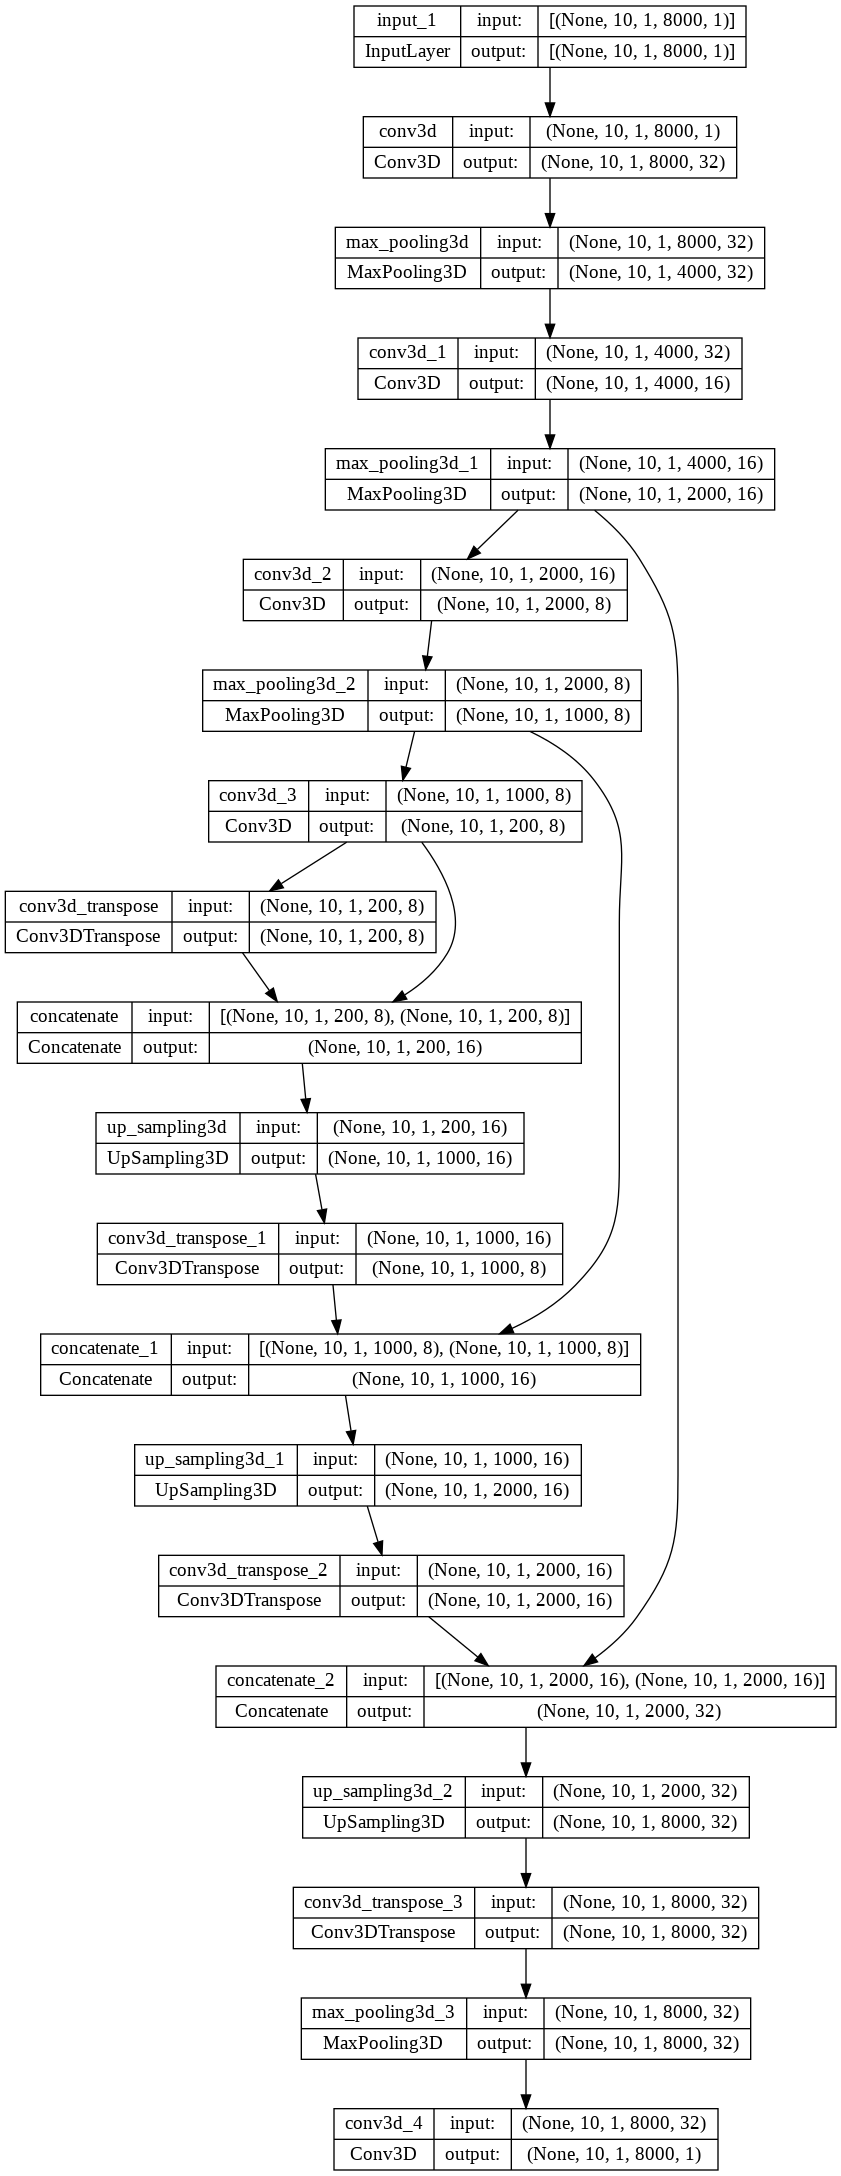

In [ ]:
from keras.utils.vis_utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, rankdir="TB", show_layer_names=True)   # rankdir="TB" for vertical display or rankdir="LR" for horizontal display

In [ ]:
predictions.shape

(1, 10, 1, 8000, 1)

In [ ]:
PREDICTION_flat = (predictions).flatten()
PREDICTION_flat.shape

PREDICTION_flat_abs = abs(PREDICTION_flat)


RESULT4D_DATASET_test.shape
RESULT4D_DATASET_test_flat = (RESULT4D_DATASET_test).flatten()
RESULT4D_DATASET_test_flat.shape

(80000,)

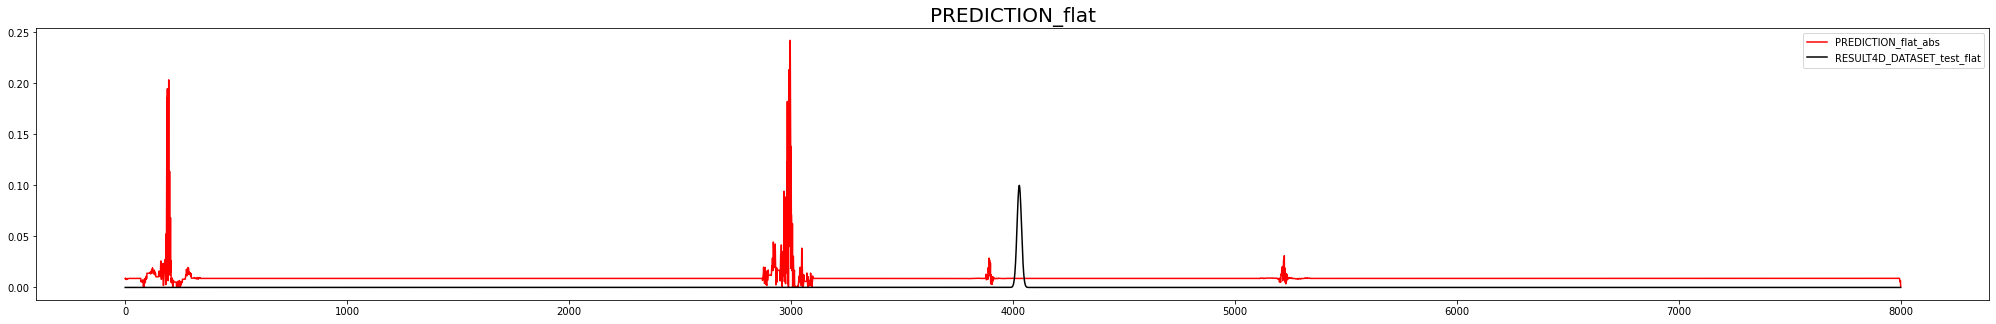

In [ ]:
plt.figure(figsize=(35, 5))
plt.title( label='PREDICTION_flat', size=20)
plt.plot(PREDICTION_flat_abs[:8000], label='PREDICTION_flat_abs', color= 'red')
#plt.plot(PREDICTION_flat[:8000], label='PREDICTION_flat', color= 'green')
plt.plot((RESULT4D_DATASET_test_flat[:8000])/10, label='RESULT4D_DATASET_test_flat', color= 'black')
plt.legend(loc='upper right')
plt.show()

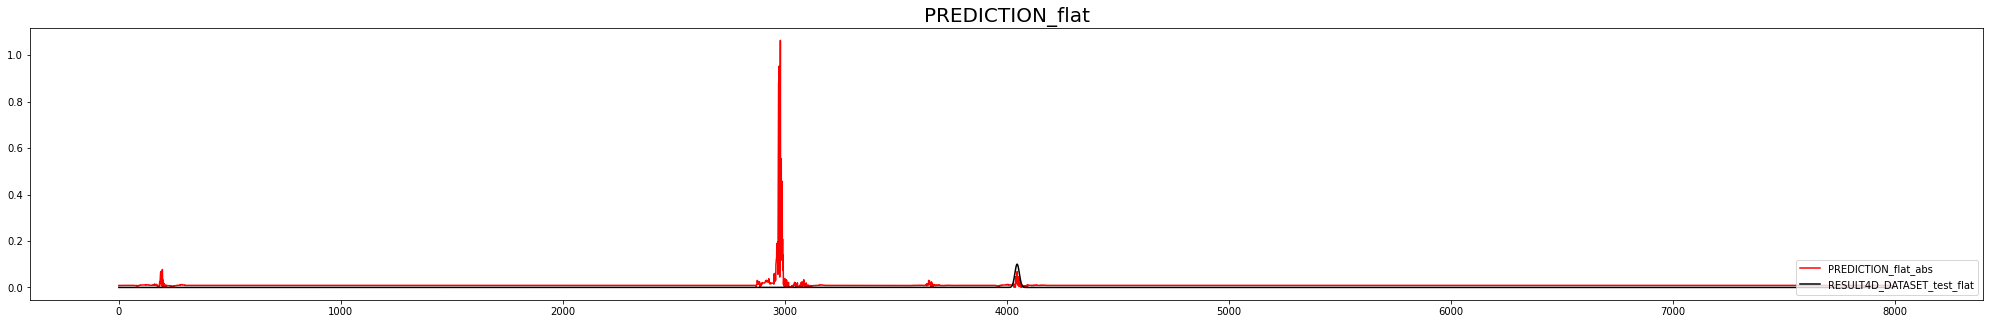

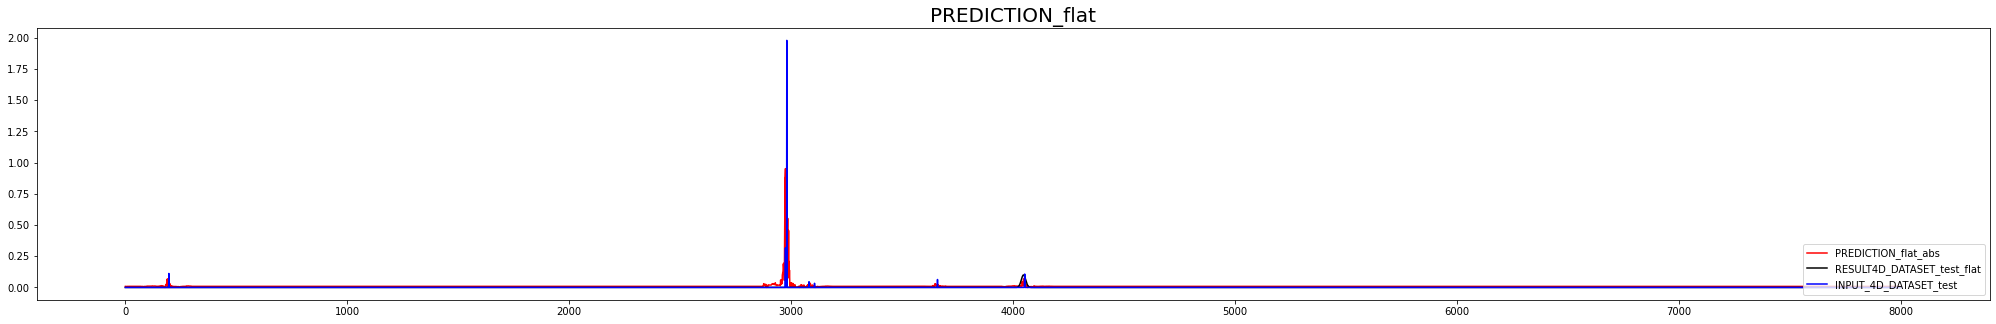

In [ ]:
N = 2  # N is the number of the test result  in this model it is an INTERGERand  ranges from 0 to 9 inclusive
Nstart = (N*8000)
Nend   = Nstart + 7999
plt.figure(figsize=(35, 5))
plt.title( label='PREDICTION_flat', size=20)
plt.plot(PREDICTION_flat_abs[Nstart:Nend], label='PREDICTION_flat_abs', color= 'red')
#plt.plot(PREDICTION_flat[Nstart:Nend], label='PREDICTION_flat', color= 'green')
plt.plot((RESULT4D_DATASET_test_flat[Nstart:Nend])/10, label='RESULT4D_DATASET_test_flat', color= 'black')
plt.legend(loc='lower right')
plt.show()

plt.figure(figsize=(35, 5))
plt.title( label='PREDICTION_flat', size=20)
plt.plot(PREDICTION_flat_abs[Nstart:Nend], label='PREDICTION_flat_abs', color= 'red')
#plt.plot(PREDICTION_flat[Nstart:Nend], label='PREDICTION_flat', color= 'blue')
plt.plot((RESULT4D_DATASET_test_flat[Nstart:Nend])/10, label='RESULT4D_DATASET_test_flat', color= 'black')
plt.plot(((INPUT_4D_DATASET_test[0:1,N:N+1,0:1,:]).flatten())/10, label='INPUT_4D_DATASET_test', color= 'blue')
plt.legend(loc='lower right')
plt.show()



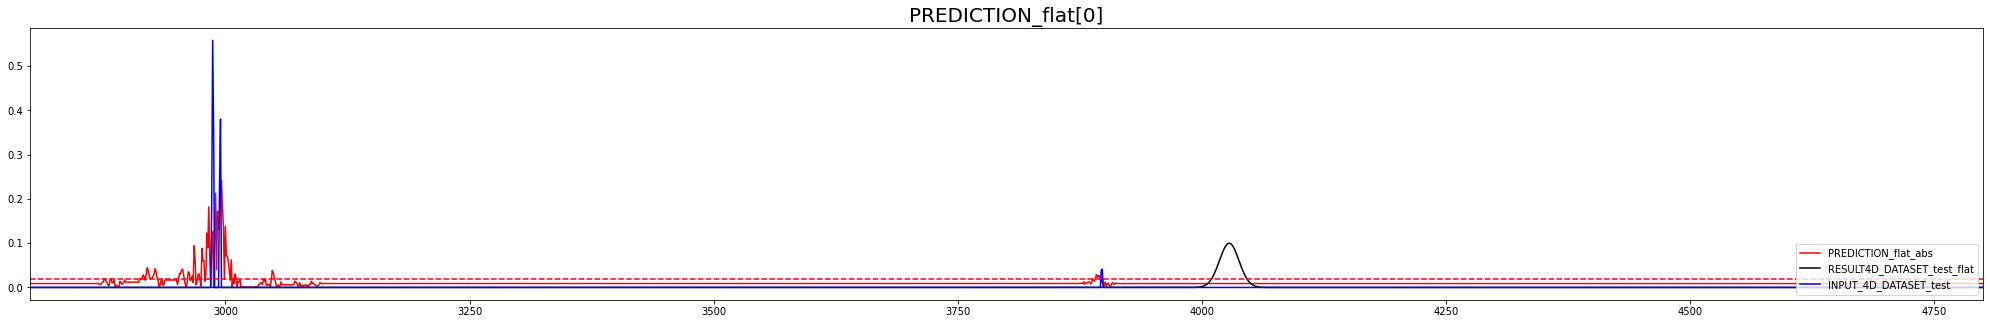

Mean value of prediction is =  0.009550477


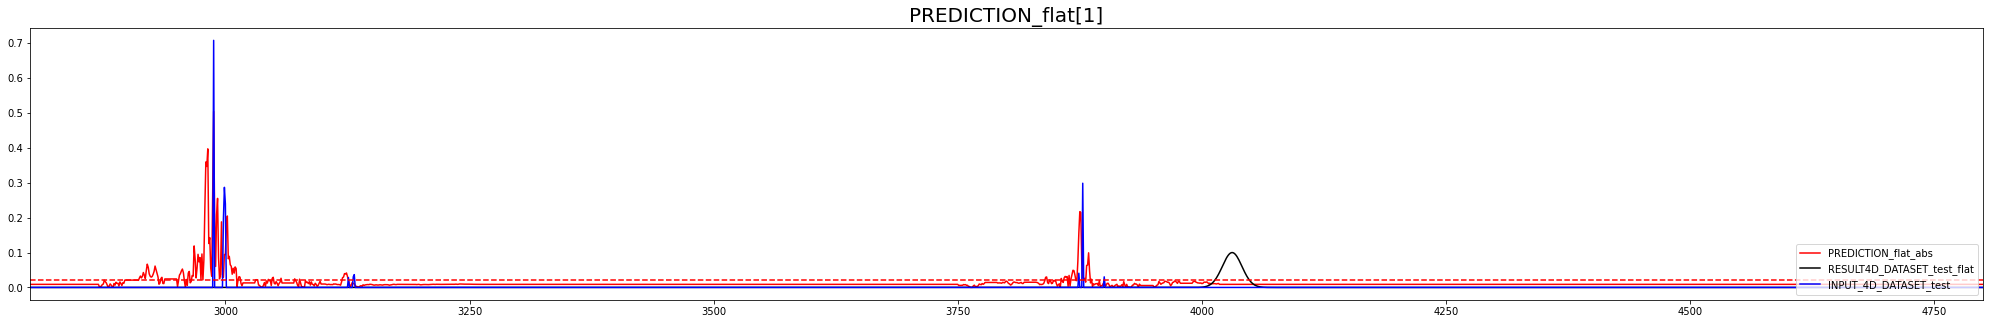

Mean value of prediction is =  0.010003388


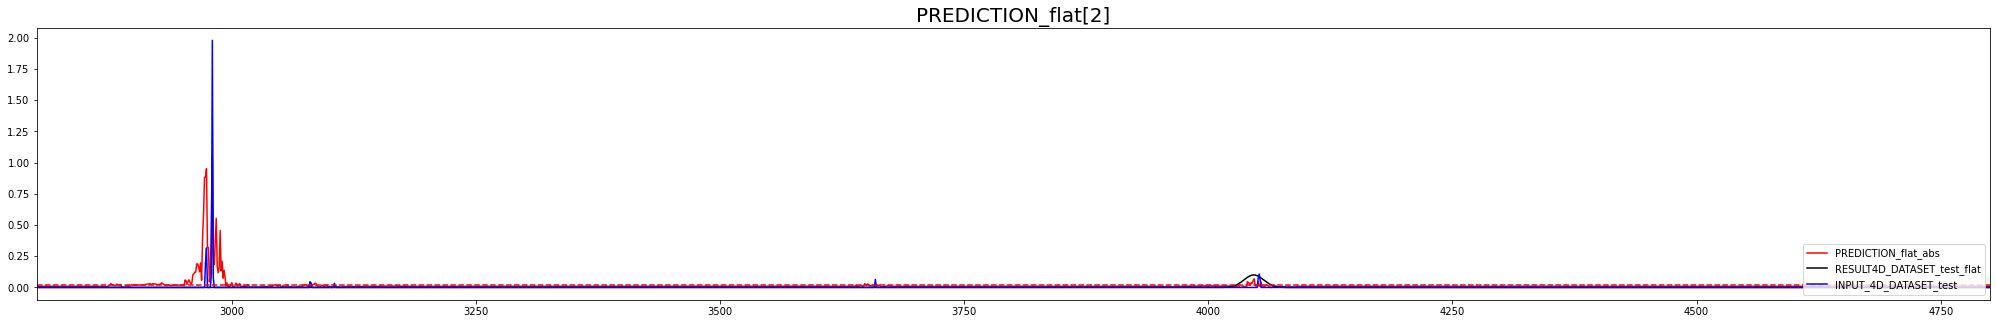

Mean value of prediction is =  0.010376393


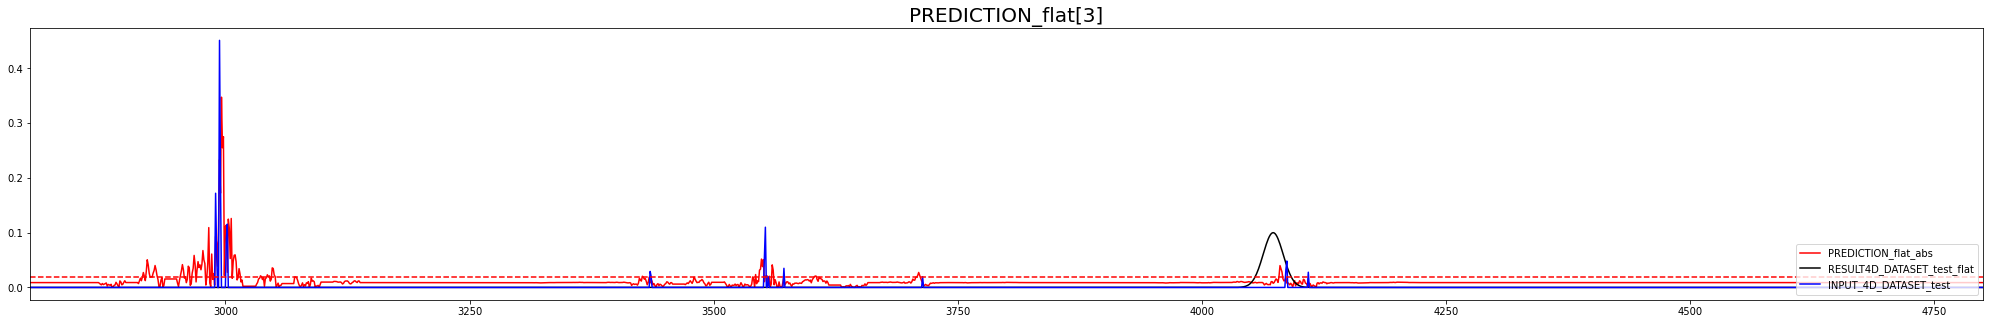

Mean value of prediction is =  0.009379815


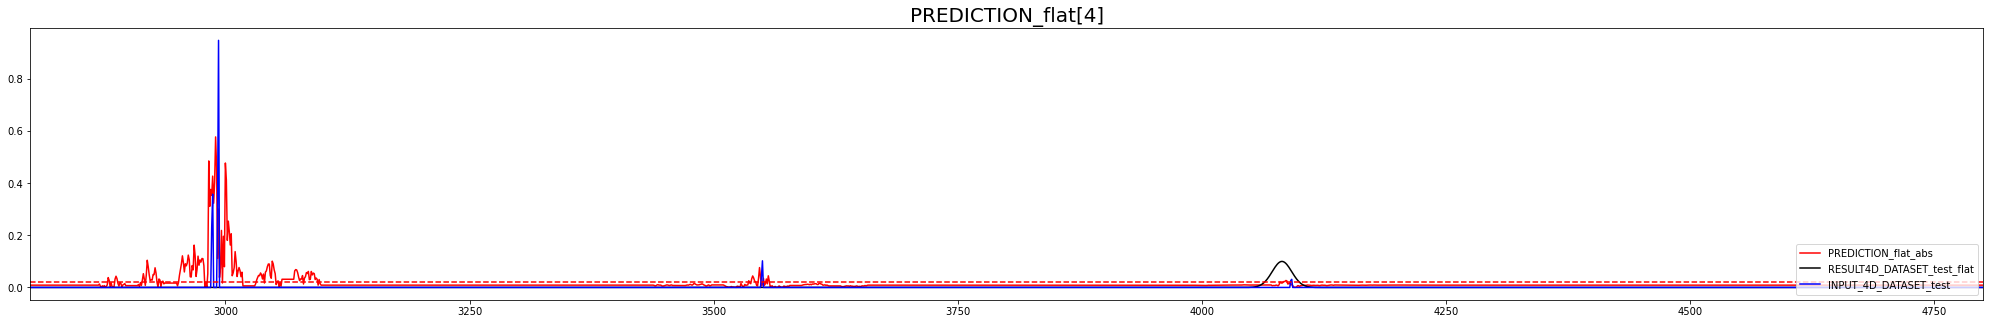

Mean value of prediction is =  0.010446814


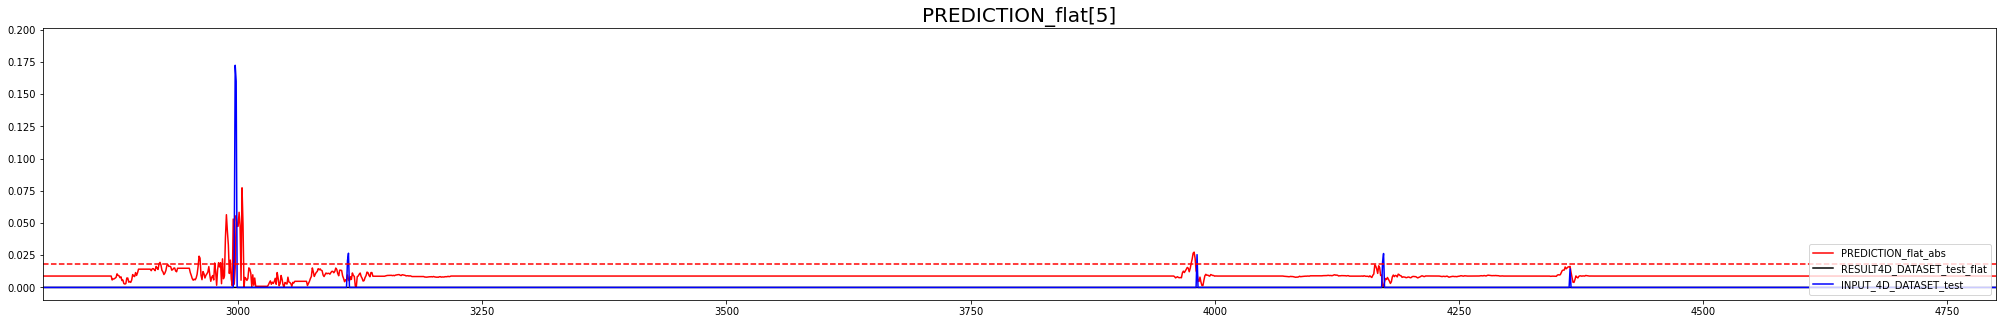

Mean value of prediction is =  0.009038168


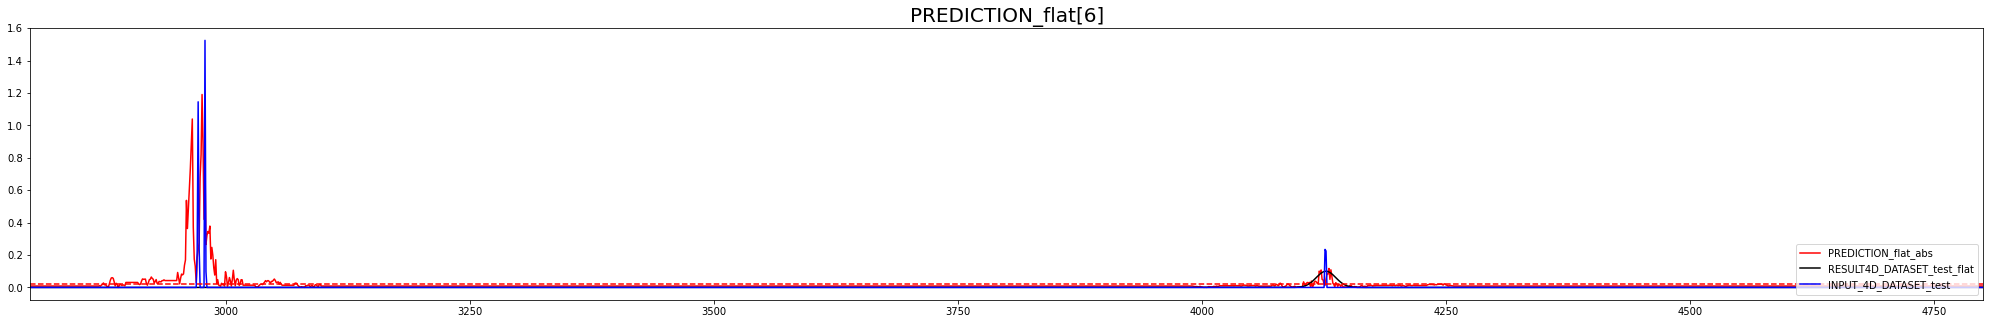

Mean value of prediction is =  0.011219428


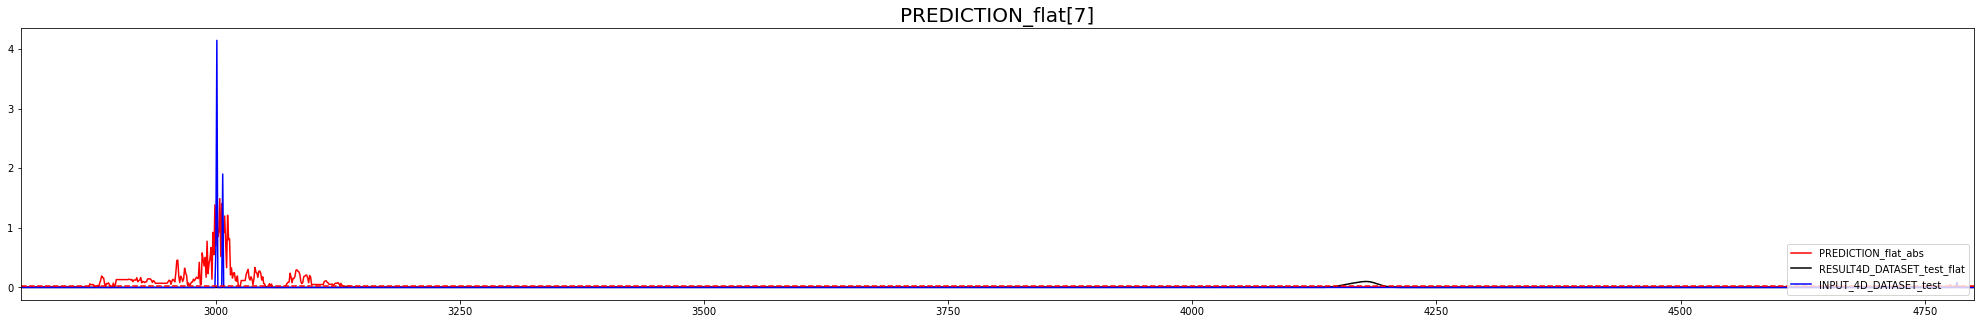

Mean value of prediction is =  0.014555797


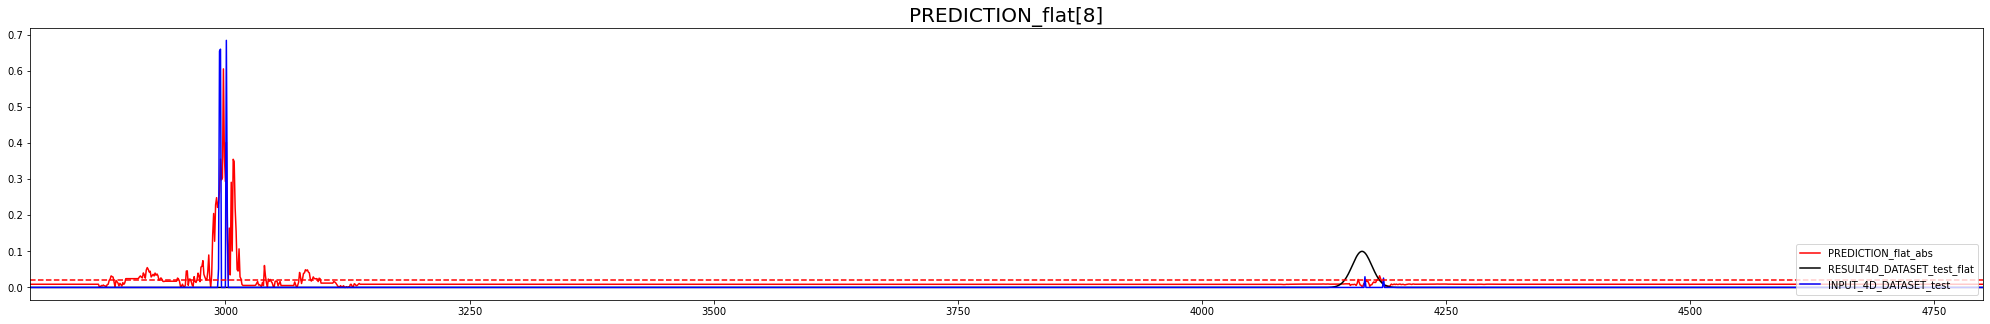

Mean value of prediction is =  0.009927902


In [ ]:
for nn in range (0, 9):
  Nstart = (nn*8000)
  Nend   = Nstart + 7999
  plt.figure(figsize=(35, 5))
  plt.title( label='PREDICTION_flat[ii]'.replace("ii", str(nn)[0]), size=20)
  plt.plot(PREDICTION_flat_abs[Nstart:Nend], label='PREDICTION_flat_abs', color= 'red')
  #plt.plot(PREDICTION_flat[Nstart:Nend], label='PREDICTION_flat', color= 'blue')
  plt.plot((RESULT4D_DATASET_test_flat[Nstart:Nend])/10, label='RESULT4D_DATASET_test_flat', color= 'black')
  plt.plot(((INPUT_4D_DATASET_test[0:1,nn:nn+1,0:1,:]).flatten())/10, label='INPUT_4D_DATASET_test', color= 'blue')
  plt.axhline(np.mean(PREDICTION_flat_abs[Nstart:Nend]*2),linestyle='--',color='red')
  plt.xlim(2800,4800)
  plt.legend(loc='lower right')
  plt.show()
  print("Mean value of prediction is = ", np.mean(PREDICTION_flat_abs[Nstart:Nend]))


In [ ]:

"""
import bottleneck as bn
import numpy as np
def rollavg_bottlneck(a,n):
    return bn.move_mean(a, window=n,min_count = None)

data = np.array([10,5,8,9,15,22,26,11,15,16,18,7])
print(rollavg_bottlneck(data, 4))
"""
import bottleneck as bn
from scipy.ndimage.interpolation import shift

for nn in range (0, 10):
  win = 20
  Nstart = (nn*8000)
  Nend   = Nstart + 7999
  plt.figure(figsize=(35, 5))
  plt.title( label='PREDICTION_flat[ii]'.replace("ii", str(nn)[0]), size=20)
  plt.plot(PREDICTION_flat_abs[Nstart:Nend], label='PREDICTION_flat_abs', color= 'red')
  #plt.plot(PREDICTION_flat[Nstart:Nend], label='PREDICTION_flat', color= 'blue')
  plt.plot((RESULT4D_DATASET_test_flat[Nstart:Nend])/10, label='RESULT4D_DATASET_test_flat', color= 'black')
  plt.plot(((INPUT_4D_DATASET_test[0:1,nn:nn+1,0:1,:]).flatten())/10, label='INPUT_4D_DATASET_test', color= 'blue')
  plt.axhline(np.mean(PREDICTION_flat_abs[Nstart:Nend]*1.5),linestyle='--',color='red')
  print("Mean value of prediction is = ", np.mean(PREDICTION_flat_abs[Nstart:Nend]))
  a = PREDICTION_flat_abs[Nstart:Nend]
  MvgAvg = bn.move_mean(a, window=win,min_count = None)
  print(MvgAvg)
  MvgAvgshft = np.roll(MvgAvg, round(-win/2))
  #MvgAvgshft = shift(MvgAvg, -50, cval=0)   #cval=np.NaN
  #plt.plot(MvgAvg, label='MvgAvg', color= 'green')
  plt.plot(MvgAvgshft, label='MvgAvgshft', color= 'grey')
  plt.xlim(2700,4500)
  plt.legend(loc='lower right')
  plt.show()



ModuleNotFoundError: ignored